### Récupération des Données et Définition des Metrics

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
plt.rcParams['figure.figsize'] = (12, 4)

In [2]:
DB_DIR = Path(os.environ.get('SUJET2_DB_DIR', 'db'))

paths = {
    'sitehist': DB_DIR / 'sitehist.csv',
    'sitepred': DB_DIR / 'sitepred.csv',
    'siteweath': DB_DIR / 'siteweath.csv',
    'zonehist': DB_DIR / 'zonehist.csv',
    'zonepred': DB_DIR / 'zonepred.csv',
}

missing = [k for k,p in paths.items() if not p.exists()]
if missing:
    print('⚠️ Fichiers manquants :', missing)
    for k in missing:
        print(' -', k, '->', paths[k])
else:
    print('✅ Tous les fichiers sont présents dans', DB_DIR.resolve())

✅ Tous les fichiers sont présents dans C:\Users\OctaveCINQUANTA\CR SYSTEM\PROJETS Build 4 Use - _octave\Sujet II\db


In [3]:
def read_semicolon_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep=';', quotechar='"', encoding='utf-8', engine='python')

raw = {}
for k, p in paths.items():
    if p.exists():
        df = read_semicolon_csv(p)
        raw[k] = df
        print(f"{k}: shape={df.shape}")

sitehist: shape=(3492, 15)
sitepred: shape=(3573, 9)
siteweath: shape=(4184, 15)
zonehist: shape=(21048, 16)
zonepred: shape=(20237, 10)


In [4]:
def to_day(s):
    return pd.to_datetime(s, errors='coerce').dt.floor('D')

sitehist = raw.get('sitehist', pd.DataFrame()).copy()
sitepred = raw.get('sitepred', pd.DataFrame()).copy()
siteweath = raw.get('siteweath', pd.DataFrame()).copy()
zonehist = raw.get('zonehist', pd.DataFrame()).copy()
zonepred = raw.get('zonepred', pd.DataFrame()).copy()

if 'dtUpdate' in sitehist.columns:
    sitehist['date'] = to_day(sitehist['dtUpdate'])
if 'date' in sitepred.columns:
    sitepred['date'] = to_day(sitepred['date'])
if 'dtUpdate' in siteweath.columns:
    siteweath['date'] = to_day(siteweath['dtUpdate'])
if 'dtUpdate' in zonehist.columns:
    zonehist['date'] = to_day(zonehist['dtUpdate'])
if 'date' in zonepred.columns:
    zonepred['date'] = to_day(zonepred['date'])

for name, df in [('sitehist', sitehist), ('sitepred', sitepred), ('siteweath', siteweath), ('zonehist', zonehist), ('zonepred', zonepred)]:
    if 'date' in df.columns:
        print(name, 'date range:', df['date'].min(), '->', df['date'].max(), 'null dates:', df['date'].isna().sum())

sitehist date range: 2023-12-19 00:00:00 -> 2026-04-02 00:00:00 null dates: 0
sitepred date range: 2024-01-26 00:00:00 -> 2026-04-10 00:00:00 null dates: 1
siteweath date range: 2024-06-10 00:00:00 -> 2026-04-10 00:00:00 null dates: 0
zonehist date range: 2024-01-27 00:00:00 -> 2026-04-02 00:00:00 null dates: 0
zonepred date range: 2024-02-23 00:00:00 -> 2026-04-10 00:00:00 null dates: 0


In [5]:
def mae(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    return float(np.mean(np.abs(y_true[m] - y_pred[m]))) if m.any() else np.nan


def rmse(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    return float(np.sqrt(np.mean((y_true[m] - y_pred[m])**2))) if m.any() else np.nan


def mape(y_true, y_pred, eps=1e-9):
    m = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > eps)
    return float(100.0 * np.mean(np.abs((y_true[m] - y_pred[m]) / y_true[m]))) if m.any() else np.nan


def bias(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    return float(np.mean(y_pred[m] - y_true[m])) if m.any() else np.nan


def metrics_row(df, y_true_col, y_pred_col):
    y_true_obj = df[y_true_col]
    y_pred_obj = df[y_pred_col]

    if isinstance(y_true_obj, pd.DataFrame):
        y_true_obj = y_true_obj.iloc[:, 0]
    if isinstance(y_pred_obj, pd.DataFrame):
        y_pred_obj = y_pred_obj.iloc[:, 0]

    y_true = pd.to_numeric(df[y_true_col], errors='coerce').to_numpy(dtype=float)
    y_pred = pd.to_numeric(df[y_pred_col], errors='coerce').to_numpy(dtype=float)

    return {
        'n': int(np.isfinite(y_true).sum()),
        'MAE': mae(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAPE_%': mape(y_true, y_pred),
        'Bias(pred-true)': bias(y_true, y_pred)
    }


def summarize_by_group(df, y_true_col, y_pred_col, group_cols):
    rows = []
    for keys, g in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        d = metrics_row(g, y_true_col, y_pred_col)
        rows.append((*keys, d['n'], d['MAE'], d['RMSE'], d['MAPE_%'], d['Bias(pred-true)']))
    out_cols = list(group_cols) + ['n','MAE','RMSE','MAPE_%','Bias(pred-true)']
    return pd.DataFrame(rows, columns=out_cols)

### Mapping des correspondances « prédiction → vérité »

On définit un mapping par niveau :
- **site** : prédictions dans `sitepred` comparées à `sitehist` (ou `siteweath` pour météo)
- **zone** : prédictions dans `zonepred` comparées à `zonehist`

In [6]:
# Mapping par défaut
# (pred_df_name, pred_col) -> (truth_df_name, truth_col)

SITE_MAP = {
    ('sitepred','totalKwh'): ('sitehist','elecTotalKwh'),
    ('sitepred','totalWater'): ('sitehist','waterM3'),
    ('sitepred','tempAmb'): ('siteweath','weath_tempAmb'),
    ('sitepred','value'): ('sitehist','totalOptimValue'),
}

ZONE_MAP = {
    ('zonepred','totalKwh'): ('zonehist','elecTotalKwh'),
    ('zonepred','totalWater'): ('zonehist','waterM3'),
    ('zonepred','tempAmb'): ('zonehist','indoorTempDegC'),
    ('zonepred','value'): ('zonehist','totalOptimValue'),
}

def filter_map(m, dfs):
    out = {}
    for (p_df, p_col), (t_df, t_col) in m.items():
        if p_df in dfs and t_df in dfs:
            if p_col in dfs[p_df].columns and t_col in dfs[t_df].columns:
                out[(p_df,p_col)] = (t_df,t_col)
    return out

DFS = {'sitehist': sitehist, 'sitepred': sitepred, 'siteweath': siteweath, 'zonehist': zonehist, 'zonepred': zonepred}

SITE_MAP = filter_map(SITE_MAP, DFS)
ZONE_MAP = filter_map(ZONE_MAP, DFS)

print('SITE_MAP utilisé:', SITE_MAP)
print('ZONE_MAP utilisé:', ZONE_MAP)

SITE_MAP utilisé: {('sitepred', 'totalKwh'): ('sitehist', 'elecTotalKwh'), ('sitepred', 'totalWater'): ('sitehist', 'waterM3'), ('sitepred', 'value'): ('sitehist', 'totalOptimValue')}
ZONE_MAP utilisé: {('zonepred', 'totalKwh'): ('zonehist', 'elecTotalKwh'), ('zonepred', 'totalWater'): ('zonehist', 'waterM3'), ('zonepred', 'tempAmb'): ('zonehist', 'indoorTempDegC'), ('zonepred', 'value'): ('zonehist', 'totalOptimValue')}


### Évaluation par metric — niveau site

Jointure par (`siteId`, `date`). Si la vérité vient de `siteweath`, on joint aussi `siteweath`.


In [7]:
# Construction dataset joint site
site_join_cols = ['siteId','date']

sitehist_d = sitehist.dropna(subset=site_join_cols).drop_duplicates(subset=site_join_cols, keep='last')
sitepred_d = sitepred.dropna(subset=site_join_cols).drop_duplicates(subset=site_join_cols, keep='last')

site_base = sitepred_d.merge(sitehist_d, on=site_join_cols, how='left', suffixes=('_pred','_hist'))

# Météo
if len(siteweath) and set(site_join_cols).issubset(siteweath.columns):
    siteweath_d = siteweath.dropna(subset=site_join_cols).drop_duplicates(subset=site_join_cols, keep='last')
    w = siteweath_d.rename(columns={c: f"weath_{c}" for c in siteweath_d.columns if c not in site_join_cols})
    site_base = site_base.merge(w, on=site_join_cols, how='left')

print('site_base shape:', site_base.shape)
display(site_base.head(3))

site_base shape: (3572, 37)


,id_pred,siteId,value,totalKwh,tempAmb,totalWater,date,usrUpdate,dtUpdate_pred,id_hist,indoorTempDegC,elecBveKwh,elecCvcKwh,elecForceKwh,elecLightingKwh,elecAggregatedKwh,elecTotalKwh,waterM3,maxUsers,totalOptimValue,startOptim,stopOptim,dtUpdate_hist,weath_id,weath_tempMin,weath_tempMax,weath_chancePluie,weath_summary,weath_djC,weath_djF,weath_indexApprox,weath_weekend,weath_airId,weath_tempAmb,weath_humidity,weath_windSpeed,weath_dtUpdate
0,1,130,0.0,102.5095,0.000000,0.170013,2024-01-26,NaN,2024-01-24 16:25:36,143.0,18.897167,0.0,18.906,0.0,0.0,0.0,181.048,0.109985,0.0,27.03,08h00,08h09,2024-01-26 00:00:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,130,0.0,205.0190,0.000000,0.340027,2024-01-27,NaN,2024-01-24 16:25:36,144.0,17.015024,0.0,50.304,0.0,0.0,0.0,90.267,0.100006,0.0,0.00,08h00,08h09,2024-01-27 00:00:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,130,0.0,299.9870,5.344191,0.423330,2024-01-28,NaN,2024-01-24 16:25:36,145.0,15.416342,0.0,36.714,0.0,0.0,0.0,114.308,0.000000,0.0,0.00,06h49,08h09,2024-01-28 00:00:00.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Évaluation par metric

site_results = []
site_results_by_site = {}

for (p_df, p_col), (t_df, t_col) in SITE_MAP.items():
    if p_col not in site_base.columns or t_col not in site_base.columns:
        continue

    g = site_base.dropna(subset=['siteId','date'])
    g = g[[*site_join_cols, p_col, t_col]].copy()

    d = metrics_row(g, t_col, p_col)
    site_results.append({
        'level': 'site',
        'pred_col': p_col,
        'true_col': t_col,
        **d
    })

    by = summarize_by_group(g, t_col, p_col, ['siteId'])
    by.insert(0, 'pred_col', p_col)
    by.insert(1, 'true_col', t_col)
    site_results_by_site[p_col] = by.sort_values('RMSE', ascending=False)

site_results = pd.DataFrame(site_results).sort_values(['RMSE'], ascending=False)
display(site_results)

,level,pred_col,true_col,n,MAE,RMSE,MAPE_%,Bias(pred-true)
0,site,totalKwh,elecTotalKwh,2911,1.165740e+06,6.125850e+07,5.001853e+03,-1.134447e+06
1,site,totalWater,waterM3,2911,1.729842e+04,1.738223e+05,3.836374e+07,1.729574e+04
2,site,value,totalOptimValue,2911,7.735626e-01,5.383931e+00,1.000778e+02,-5.278063e-01


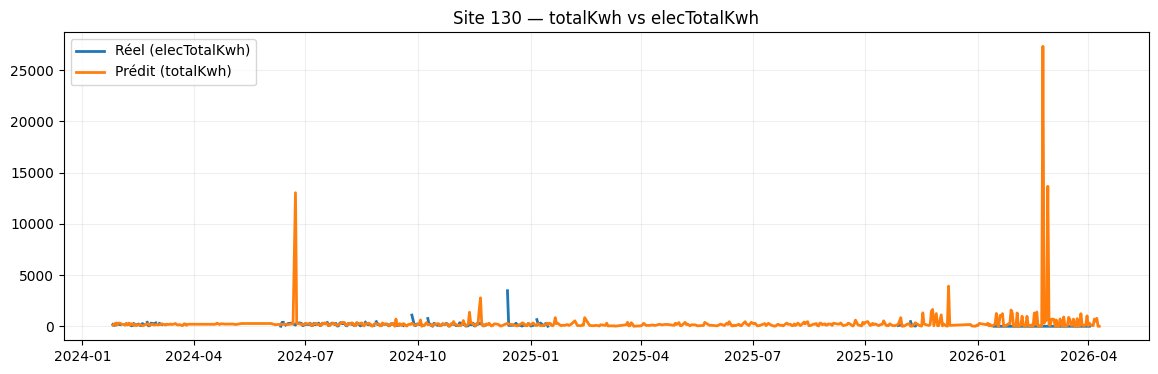

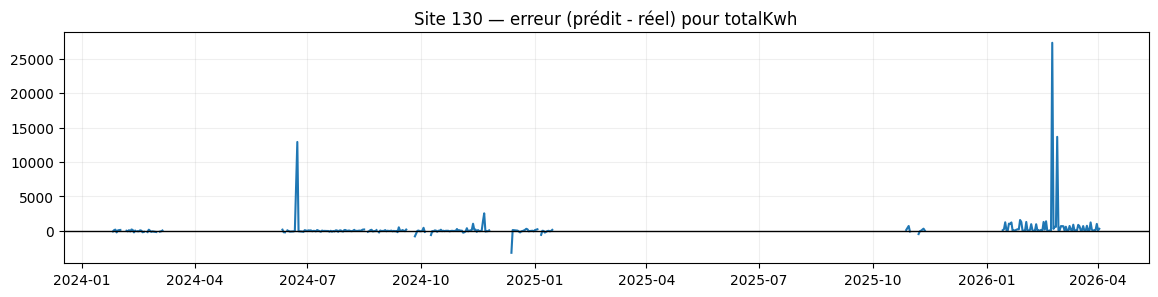

In [9]:
# Quelques graphes — choisir une metric + un site

if len(site_results):
    METRIC = site_results.iloc[0]['pred_col']  # pire RMSE
    SITE_ID = site_base['siteId'].dropna().astype(int).unique()[0]

    true_col = site_results[site_results['pred_col']==METRIC].iloc[0]['true_col']

    g = site_base[site_base['siteId']==SITE_ID].sort_values('date')
    g = g[['date', METRIC, true_col]].copy()

    plt.figure(figsize=(14,4))
    plt.plot(g['date'], pd.to_numeric(g[true_col], errors='coerce'), label=f"Réel ({true_col})", linewidth=2)
    plt.plot(g['date'], pd.to_numeric(g[METRIC], errors='coerce'), label=f"Prédit ({METRIC})", linewidth=2)
    plt.title(f"Site {SITE_ID} — {METRIC} vs {true_col}")
    plt.legend(); plt.grid(True, alpha=.2); plt.show()

    err = pd.to_numeric(g[METRIC], errors='coerce') - pd.to_numeric(g[true_col], errors='coerce')
    plt.figure(figsize=(14,3))
    plt.plot(g['date'], err)
    plt.title(f"Site {SITE_ID} — erreur (prédit - réel) pour {METRIC}")
    plt.axhline(0, color='black', linewidth=1)
    plt.grid(True, alpha=.2); plt.show()

### Évaluation par metric — niveau zone

Jointure par (`siteId`, `zoneId`, `date`).


In [10]:
# Construction dataset joint zone
zone_join_cols = ['siteId','zoneId','date']

zonehist_d = zonehist.dropna(subset=zone_join_cols).drop_duplicates(subset=zone_join_cols, keep='last')
zonepred_d = zonepred.dropna(subset=zone_join_cols).drop_duplicates(subset=zone_join_cols, keep='last')

zone_base = zonepred_d.merge(zonehist_d, on=zone_join_cols, how='left', suffixes=('_pred','_hist'))
print('zone_base shape:', zone_base.shape)
display(zone_base.head(3))

zone_base shape: (20237, 24)


,id_pred,siteId,zoneId,value,totalKwh,tempAmb,totalWater,date,usrUpdate,dtUpdate_pred,id_hist,indoorTempDegC,elecBveKwh,elecCvcKwh,elecForceKwh,elecLightingKwh,elecAggregatedKwh,elecTotalKwh,waterM3,maxUsers,totalOptimValue,startOptim,stopOptim,dtUpdate_hist
0,89,130,285,0.0,115.0,20.628284,0.299988,2024-02-23,NaN,2024-02-21 12:33:36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,90,130,285,0.0,115.0,20.628284,0.299988,2024-02-24,NaN,2024-02-21 12:33:37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,91,130,285,0.0,115.0,20.628284,0.299988,2024-02-25,NaN,2024-02-21 12:33:37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Évaluation par metric (zone)

zone_results = []
zone_results_by_zone = {}

for (p_df, p_col), (t_df, t_col) in ZONE_MAP.items():
    if p_col not in zone_base.columns or t_col not in zone_base.columns:
        continue

    g = zone_base.dropna(subset=['siteId','zoneId','date'])
    g = g[[*zone_join_cols, p_col, t_col]].copy()

    d = metrics_row(g, t_col, p_col)
    zone_results.append({
        'level': 'zone',
        'pred_col': p_col,
        'true_col': t_col,
        **d
    })

    by = summarize_by_group(g, t_col, p_col, ['siteId','zoneId'])
    by.insert(0, 'pred_col', p_col)
    by.insert(1, 'true_col', t_col)
    zone_results_by_zone[p_col] = by.sort_values('RMSE', ascending=False)

zone_results = pd.DataFrame(zone_results).sort_values(['RMSE'], ascending=False)
display(zone_results)

,level,pred_col,true_col,n,MAE,RMSE,MAPE_%,Bias(pred-true)
0,zone,totalKwh,elecTotalKwh,18002,804189.628211,5.401850e+07,4.416427e+04,-40637.827656
1,zone,totalWater,waterM3,18002,3212.127979,7.665490e+04,2.209365e+07,3211.676341
3,zone,value,totalOptimValue,18002,27.681077,8.387904e+01,1.000000e+02,17.370469
2,zone,tempAmb,indoorTempDegC,18002,3.075513,6.743173e+00,2.685293e+01,-0.182065


### Export des résultats

Exports dans `output` :
- `metrics_summary_all_metrics.csv` (résumé global par métrique, site+zone)
- `metrics_by_site_<metric>.csv`
- `metrics_by_zone_<metric>.csv`


In [12]:
OUT_DIR = Path('output')
OUT_DIR.mkdir(parents=True, exist_ok=True)

summary = pd.concat([site_results, zone_results], ignore_index=True) if len(site_results) or len(zone_results) else pd.DataFrame()

if len(summary):
    summary.to_csv(OUT_DIR / 'metrics_summary_all_metrics.csv', index=False)
    print('Wrote', OUT_DIR / 'metrics_summary_all_metrics.csv')
    display(summary)

for metric, df in site_results_by_site.items():
    p = OUT_DIR / f'metrics_by_site_{metric}.csv'
    df.to_csv(p, index=False)
    print('Wrote', p)

for metric, df in zone_results_by_zone.items():
    p = OUT_DIR / f'metrics_by_zone_{metric}.csv'
    df.to_csv(p, index=False)
    print('Wrote', p)

Wrote output\metrics_summary_all_metrics.csv


,level,pred_col,true_col,n,MAE,RMSE,MAPE_%,Bias(pred-true)
0,site,totalKwh,elecTotalKwh,2911,1.165740e+06,6.125850e+07,5.001853e+03,-1.134447e+06
1,site,totalWater,waterM3,2911,1.729842e+04,1.738223e+05,3.836374e+07,1.729574e+04
2,site,value,totalOptimValue,2911,7.735626e-01,5.383931e+00,1.000778e+02,-5.278063e-01
3,zone,totalKwh,elecTotalKwh,18002,8.041896e+05,5.401850e+07,4.416427e+04,-4.063783e+04
4,zone,totalWater,waterM3,18002,3.212128e+03,7.665490e+04,2.209365e+07,3.211676e+03
5,zone,value,totalOptimValue,18002,2.768108e+01,8.387904e+01,1.000000e+02,1.737047e+01
6,zone,tempAmb,indoorTempDegC,18002,3.075513e+00,6.743173e+00,2.685293e+01,-1.820650e-01


Wrote output\metrics_by_site_totalKwh.csv
Wrote output\metrics_by_site_totalWater.csv
Wrote output\metrics_by_site_value.csv
Wrote output\metrics_by_zone_totalKwh.csv
Wrote output\metrics_by_zone_totalWater.csv
Wrote output\metrics_by_zone_tempAmb.csv
Wrote output\metrics_by_zone_value.csv
